In [2]:
import rasterio as rio
import numpy as np

In [3]:
# Load already projected and saved 1km DEM tif

def grid_centers(profile):
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

# Emma: with rio.open(r"C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/mros-precipitation-phase-product-prototype/DEM_1km.tif") as src:
# Zeed:
with rio.open(r"../DEM_1km.tif") as src:
    dem1k_profile = src.profile   # metadata
    dem1k_data = src.read(1)      # pixel values

    # Optional extras
    dem_crs = src.crs             # CRS object
    dem_bounds = src.bounds       # bounding box
    dem_transform = src.transform # affine transform

grid_xy = grid_centers(dem1k_profile)
grid_elev = dem1k_data.ravel()
proj_crs = dem1k_profile["crs"]

print(f"DEM 1-km grid: {dem1k_profile['width']} x {dem1k_profile['height']} | "
      f"res ≈ {abs(dem1k_profile['transform'].a)} m")


DEM 1-km grid: 324 x 486 | res ≈ 0.00925926088637072 m


In [4]:
print("DEM shape:", dem1k_data.shape)
print("Min elevation:", np.nanmin(dem1k_data))
print("Max elevation:", np.nanmax(dem1k_data))
print("Bounds:", dem_bounds)
print("CRS:", dem_crs)

DEM shape: (486, 324)
Min elevation: 16.721706
Max elevation: 4184.6367
Bounds: BoundingBox(left=-121.00000316133459, bottom=35.49999932558698, right=-118.00000263415048, top=40.00000011636315)
CRS: EPSG:4326


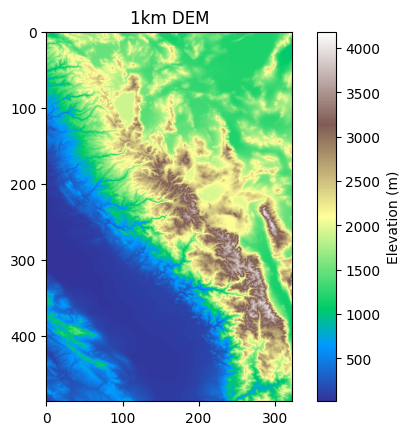

In [5]:
import matplotlib.pyplot as plt

plt.imshow(dem1k_data, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.title("1km DEM")
plt.show()

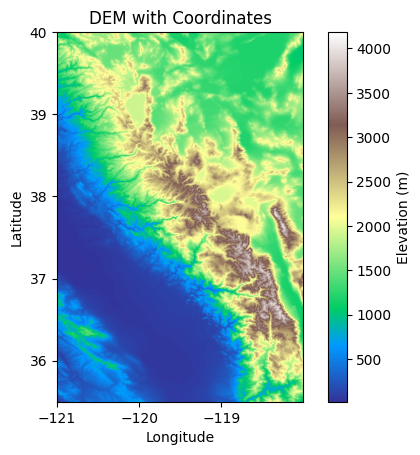

In [6]:
plt.imshow(dem1k_data, cmap="terrain",
           extent=[dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top])
plt.colorbar(label="Elevation (m)")
plt.title("DEM with Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [7]:
for i in range(0, len(grid_xy), len(grid_xy)//5):  # print 5 samples
    print("X:", grid_xy[i,0], "Y:", grid_xy[i,1], "Elev:", grid_elev[i])


X: -120.9953735308914 Y: 39.99537048591996 Elev: 1153.4142
X: -120.40278083416368 Y: 39.097222179942 Elev: 1903.5872
X: -119.81018813743596 Y: 38.19907387396404 Elev: 2657.5815
X: -119.21759544070822 Y: 37.300925567986084 Elev: 2531.1858
X: -118.6250027439805 Y: 36.40277726200812 Elev: 3091.3328
X: -118.03241004725277 Y: 35.50462895603016 Elev: 1052.0588


In [30]:
import numpy as np, rasterio as rio, io, base64
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_bounds
from PIL import Image
import folium
import matplotlib.pyplot as plt

TIF_PATH = r"../DEM_1km.tif"   # input file path
HTML_OUT = "dem_map.html"      # output file path
MAX_DIM = 600

with rio.open(TIF_PATH) as src:
    dem = src.read(1).astype("float32")
    src_bounds = src.bounds
    src_crs = src.crs
    nodata = src.nodata
    dem = np.where(np.isfinite(dem) & ((nodata is None) | (dem != nodata)), dem, np.nan)

    # Reproject bounds to WGS84 (lat/lon) for Leaflet/Folium
    lon_min, lat_min, lon_max, lat_max = transform_bounds(src_crs, "EPSG:4326",
                                                          src_bounds.left, src_bounds.bottom,
                                                          src_bounds.right, src_bounds.top,
                                                          densify_pts=21)

    # Choose downsampled size (keep aspect ratio based on src array)
    h, w = dem.shape
    if w >= h:
        new_w = min(w, MAX_DIM)
        new_h = max(1, int(h * (new_w / w)))
    else:
        new_h = min(h, MAX_DIM)
        new_w = max(1, int(w * (new_h / h)))

    # Reproject DEM directly into a WGS84 grid sized new_h x new_w
    dst_transform = from_bounds(lon_min, lat_min, lon_max, lat_max, new_w, new_h)
    dem_wgs = np.empty((new_h, new_w), dtype="float32")
    reproject(
        source=dem,
        destination=dem_wgs,
        src_transform=src.transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs="EPSG:4326",
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )

# Color PNG overlay
cmap = plt.get_cmap("terrain")
finite = np.isfinite(dem_wgs)
if finite.any():
    vmin, vmax = np.nanpercentile(dem_wgs, [2, 98])
    if vmin == vmax:
        vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 1.0

norm = np.clip((dem_wgs - vmin) / (vmax - vmin), 0, 1)
rgba = cmap(norm, bytes=True)
rgba[..., 3] = np.where(finite, 255, 0).astype(np.uint8)

img = Image.fromarray(rgba, mode="RGBA")
buf = io.BytesIO(); img.save(buf, format="PNG")
png_b64 = base64.b64encode(buf.getvalue()).decode("ascii")

# Compact elevation payload (Int16 decimeters) for JS sampling
scale = 10.0
arr_scaled = np.full_like(dem_wgs, fill_value=np.iinfo(np.int16).min, dtype=np.int16)
arr_scaled[finite] = np.clip(
    np.round(dem_wgs[finite] * scale),
    np.iinfo(np.int16).min + 1,
    np.iinfo(np.int16).max
).astype(np.int16)
elev_b64 = base64.b64encode(arr_scaled.tobytes()).decode("ascii")

# Build Folium map
center_lat = (lat_min + lat_max) / 2.0
center_lon = (lon_min + lon_max) / 2.0
m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="cartodbpositron")
folium.raster_layers.ImageOverlay(
    image=f"data:image/png;base64,{png_b64}",
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.7,
    zindex=1
).add_to(m)

# Bind click handler to THIS map specifically
map_var = m.get_name()  # e.g., "map_123abc"
click_js = f"""
<script>
(function() {{
  const map = {map_var};
  const width = {arr_scaled.shape[1]};
  const height = {arr_scaled.shape[0]};
  const left = {lon_min};
  const right = {lon_max};
  const bottom = {lat_min};
  const top = {lat_max};
  const scale = {scale};
  const NODATA = -32768;

  function b64ToUint8Array(b64str) {{
    const raw = atob(b64str);
    const arr = new Uint8Array(raw.length);
    for (let i = 0; i < raw.length; i++) arr[i] = raw.charCodeAt(i);
    return arr;
  }}
  const elev = new Int16Array(b64ToUint8Array("{elev_b64}").buffer);

  function sampleElev(lat, lon) {{
    const col = Math.floor((lon - left) / (right - left) * width);
    const row = Math.floor((top - lat) / (top - bottom) * height);
    if (row < 0 || row >= height || col < 0 || col >= width) return null;
    const val = elev[row * width + col];
    if (val === NODATA) return null;
    return val / scale;
  }}

  map.on('click', function(e) {{
    const lat = e.latlng.lat, lon = e.latlng.lng;
    const elevM = sampleElev(lat, lon);
    const html = (elevM == null)
      ? `Lat: ${'{'}lat.toFixed(5){'}'}<br>Lon: ${'{'}lon.toFixed(5){'}'}<br><b>Elevation:</b> No data`
      : `Lat: ${'{'}lat.toFixed(5){'}'}<br>Lon: ${'{'}lon.toFixed(5){'}'}<br><b>Elevation:</b> ${'{'}elevM.toFixed(2){'}'} m`;
    L.popup().setLatLng([lat, lon]).setContent(html).openOn(map);
  }});
}})();
</script>
"""
m.get_root().html.add_child(folium.Element(click_js))
m.save(HTML_OUT)
print(f"Saved {HTML_OUT}. Open it and click anywhere on the overlay to see elevation.")


Saved dem_map.html. Open it and click anywhere on the overlay to see elevation.



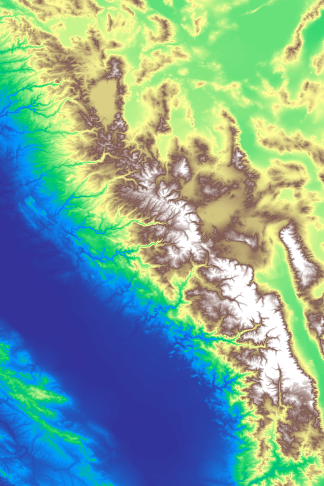

In [31]:
m